In [2]:
import json
import re
import random

from collections import defaultdict, Counter
from dataclasses import dataclass
from ordered_set import OrderedSet # might have to pip install this
from PIL import Image

from typing import List, Union, Iterable

In [3]:
def read_json(path):
    with open(path, "r") as f:
        return json.load(f)


def write_json(path, data):
    with open(path, "w") as f:
        json.dump(data, f, indent=4)

In [4]:
questions = read_json("../data/CLEVR_v1.0/questions/CLEVR_val_questions.json")
metadata = read_json("../data/CLEVR_v1.0/scenes/CLEVR_val_scenes.json")

## Designing Referring Expressions for Objects

The set of objects and their attributes are listed as follows:

In [5]:
metadata['scenes'][0]['objects']

[{'color': 'brown',
  'size': 'large',
  'rotation': 178.92387258999463,
  'shape': 'cylinder',
  '3d_coords': [-1.4937210083007812, -1.9936031103134155, 0.699999988079071],
  'material': 'rubber',
  'pixel_coords': [119, 131, 10.801968574523926]},
 {'color': 'gray',
  'size': 'large',
  'rotation': 243.405459279722,
  'shape': 'cube',
  '3d_coords': [1.555708646774292, -2.104736566543579, 0.699999988079071],
  'material': 'rubber',
  'pixel_coords': [198, 190, 8.60103988647461]},
 {'color': 'green',
  'size': 'small',
  'rotation': 230.45235024165092,
  'shape': 'cylinder',
  '3d_coords': [-2.342184543609619, -0.5205014944076538, 0.3499999940395355],
  'material': 'rubber',
  'pixel_coords': [161, 118, 12.372727394104004]},
 {'color': 'purple',
  'size': 'large',
  'rotation': 31.654351858799153,
  'shape': 'sphere',
  '3d_coords': [-0.8073106408119202, 1.914123773574829, 0.699999988079071],
  'material': 'metal',
  'pixel_coords': [282, 100, 12.495001792907715]},
 {'color': 'gray',
 

We largely care about 4 things: size, color, material, shape. Since each unmodified object is referred using its shape, we will treat shape as the Noun part of the adjectival Noun Phrase (NP). The modifier order would be: size > color > material. That is, `large green rubber cylinder` as opposed to `green large rubber cylinder` or any other combination.

But in order to generate the referring expression we wanna take care of certain redundancies:

1. If there are more than one objects, we must refer to them using uniquely identifiable attributes.
2. If all objects have the same attribute (size/color/material), we skip that attribute in the NP.
3. If there's just one type of object in the scene, we will not bother describing its features -- e.g., `the sphere` is ok if there's just one sphere.

To implement this, we will use the code below:

In [6]:
@dataclass
class CLEVRObject:
    '''Defines a CLEVR Object and provides helper functions that allow us to perform modification of the NP, list its unique features, etc.'''
    size: str
    color: str
    material: str
    shape: str
    
    def __post_init__(self):
        # these are listed in this manner so that we can convert from features to object and back.
        self.modifying_features = OrderedSet([f"size:{self.size}", f"color:{self.color}", f"material:{self.material}"])
        self.modifiers = OrderedSet([self.size, self.color, self.material])

    def modify(self, shape_only=False):
        if shape_only:
            return self.shape
        else:
            modifiers = ' '.join(self.modifiers)
            noun_phrase = f"{modifiers} {self.shape}"
            noun_phrase = re.sub(r'\s\s+', ' ', noun_phrase)
            return noun_phrase
    
def features2obj(features: OrderedSet, shape: str):
    """Parse object given features."""
    feats = defaultdict(lambda : "")
    for feat in features:
        attribute, value = feat.split(":")
        feats[attribute] = value
    return CLEVRObject(feats['size'], feats['color'], feats['material'], shape)

def distinguishing_features(lst: List[Iterable]):
    """Overthought and overengineered function to compute uniquely identifiable features of entries in the input."""
    unique_ids = [item - OrderedSet.intersection(*lst) for item in lst]
    for j, item in enumerate(unique_ids):
        leftover = [entry for i, entry in enumerate(unique_ids) if i != j]
        for entry in leftover:
            if item.issubset(entry):
                return False

    return unique_ids

### Algorithm to generate referring expressions:

For a given entry in the scene:

1. get its object representation as well as its index in the object list
2. initialize `object_strings` the variable that will hold all the string representations of the object as they will appear in the question
3. for each case:
    1. if there are more than one entries per shape:
        1. get its distinguishing features --> this will usually prune the original object representation by eliminating one or more redundant features
        2. check if it's possible to have unique identification (if not then flag it)
        3. get the string representation by parsing the pruned representation
    2. else, just get the shape, no modification needed (we can change it to randomly include modifiers if we want, later...)
    3. store object strings in the same index order as listed in the raw entry.


Let's test this with the first entry, which looks like as follows:

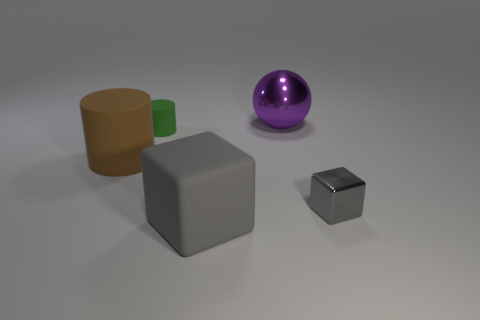

In [67]:
image = Image.open("../data/CLEVR_v1.0/images/val/CLEVR_val_000000.png").convert("RGB")
image

In [7]:
metadata_entry = metadata['scenes'][0]['objects']

for entry in metadata_entry:
    print(entry['shape'])

cylinder
cube
cylinder
sphere
cube


In [8]:
shapes = defaultdict(list)
objects = []
for i, obj in enumerate(metadata_entry):
    obj = CLEVRObject(obj['size'], obj['color'], obj['material'], obj['shape'])
    objects.append(obj)
    shapes[obj.shape].append((obj, i))

object_strings = ["" for _ in objects]

for shape, entries in shapes.items():
    objs, indices = list(zip(*entries))
    if len(entries) > 1:

        dfs = distinguishing_features([o.modifying_features for o in objs])

        if not dfs:
            for idx in indices:
                object_strings[idx] = "FAILURE" # Set all objects in this scene to "FAILURE" if no distinguishing features found
        else:
            for obj, idx in zip(dfs, indices):
                object_strings[idx] = features2obj(obj, shape).modify()
    else:
        # default reference = just the shape?
        object_strings[indices[0]] = objs[0].modify(shape_only=True)

In [9]:
object_strings

['large brown cylinder',
 'large rubber cube',
 'small green cylinder',
 'sphere',
 'small metal cube']

## Interpretation of scene relationship entries

The scene relationships can be explained using the following example:

In [10]:
metadata["scenes"][0]["relationships"]

{'right': [[1, 2, 3, 4], [3, 4], [1, 3, 4], [4], []],
 'behind': [[2, 3], [0, 2, 3, 4], [3], [], [0, 2, 3]],
 'front': [[1, 4], [], [0, 1, 4], [0, 1, 2, 4], [1]],
 'left': [[], [0, 2], [0], [0, 1, 2], [0, 1, 2, 3]]}

In [13]:
relative = {"right": "left", "left": "right", "front": "behind", "behind": "front"}

In [ ]:
for scene in metadata["scenes"]:
    num_objects = len(scene["objects"])
    for rel, ls in scene["relationships"].items():
        ls1, ls2 = ls, scene["relationships"][relative[rel]]
        added = [subls1 + subls2 for subls1, subls2 in zip(ls1, ls2)]
        for i in added:
            assert len(i) == (num_objects-1) 

Let's take the first relation, "right":

```'right': [[1, 2, 3, 4], [3, 4], [1, 3, 4], [4], []]```

Here we care about two things:
1) the index of the entries --> indicates the index of the object 
2) the entries themselves --> each entry consists of a list of numbers which denote the indices of the objects that have a valid relation to the object with the above index.


Therefore, in our example:
- objects with indices 1,2,3,4 are to the right of the object with index 0
- objects with indices 3,4 are to the right of the object with index 1
- objects with indices 1,3,4 are to the right of the object with index 2
- ... and so on

This is easy to implement, for example:

In [73]:
rights = metadata["scenes"][0]["relationships"]['right']

for idx, entry in enumerate(rights):
    for j in entry:
        print(f"Is the {object_strings[j]} to the right of the {object_strings[idx]}? -> Yes")

Is the large rubber cube to the right of the large brown cylinder? -> Yes
Is the small green cylinder to the right of the large brown cylinder? -> Yes
Is the sphere to the right of the large brown cylinder? -> Yes
Is the small metal cube to the right of the large brown cylinder? -> Yes
Is the sphere to the right of the large rubber cube? -> Yes
Is the small metal cube to the right of the large rubber cube? -> Yes
Is the large rubber cube to the right of the small green cylinder? -> Yes
Is the sphere to the right of the small green cylinder? -> Yes
Is the small metal cube to the right of the small green cylinder? -> Yes
Is the small metal cube to the right of the sphere? -> Yes


In [178]:
for scene in metadata['scenes']:
    rels = scene['relationships']
    if rels == 'right':
        for idx, entry in enumerate(rels):
            for j in entry:
                print(f"Is the {object_strings[j]} to the right of the {object_strings[idx]}? -> Yes")
    elif rels == 'left':
        for idx, entry in enumerate(rels):
            for j in entry:
                print(f"Is the {object_strings[j]} to the left of the {object_strings[idx]}? -> Yes")
    elif rels == 'front':
        for idx, entry in enumerate(rels):
            for j in entry:
                print(f"Is the {object_strings[j]} in front of the {object_strings[idx]}? -> Yes")
    elif rels == 'behind':
        for idx, entry in enumerate(rels):
            for j in entry:
                print(f"Is the {object_strings[j]} behind the {object_strings[idx]}? -> Yes")

## Negative Sampling

We don't want to train the model only on the set of questions that target existent relations - their answers will always be "Yes"

So we also want questions whose answer is "No". One simple way is to swap the arguments of the relation.


In [74]:
for idx, entry in enumerate(rights):
    for j in entry:
        print(f"Is the {object_strings[idx]} to the right of the {object_strings[j]}? -> No")

Is the large brown cylinder to the right of the large rubber cube? -> No
Is the large brown cylinder to the right of the small green cylinder? -> No
Is the large brown cylinder to the right of the sphere? -> No
Is the large brown cylinder to the right of the small metal cube? -> No
Is the large rubber cube to the right of the sphere? -> No
Is the large rubber cube to the right of the small metal cube? -> No
Is the small green cylinder to the right of the large rubber cube? -> No
Is the small green cylinder to the right of the sphere? -> No
Is the small green cylinder to the right of the small metal cube? -> No
Is the sphere to the right of the small metal cube? -> No


Finally, we dont want to include all possible questions, and probably want to avoid including both pairs of questions (positive/negative) for all cases, so here's where we can do a bit of random sampling - I will let you do this, and design how we should go about doing it.

# Random Sampling

Let's first find out how many pairs of questions (positive/negative) for all cases we have in total in the validation set:

In [32]:
count_relationships = Counter(metadata["scenes"][0]["relationships"].keys())
count_relationships

Counter({'right': 1, 'behind': 1, 'front': 1, 'left': 1})

In [138]:
def count_relationship_pairs(metadata, relation_type='right'):
    """Count achievable question pairs for a given relation type across all scenes."""
    total_positive, total_negative = 0, 0
    
    for scene in metadata['scenes']:
        for type, relationships in scene['relationships'].items():
            if type == relation_type: # skip other relation types
                for entry in relationships:
                    total_positive += len(entry)
                    total_negative += len(entry)
    
    return total_positive, total_negative

In [142]:
relation_types = ['left', 'right', 'front', 'behind']
total_counts = {}

for rel_type in relation_types:
    pos, neg = count_relationship_pairs(metadata, rel_type)
    total_counts[rel_type] = {'positive': pos, 'negative': neg}
    print(f"{rel_type.capitalize()} relations:")
    print(f"  Positive/Negative pairs: {pos}")

total_positive = sum(counts['positive'] for counts in total_counts.values())
total_negative = sum(counts['negative'] for counts in total_counts.values())
print(f"OVERALL TOTALS:")
print(f"Grand total pairs: {total_positive + total_negative}")

Left relations:
  Positive/Negative pairs: 306862
Right relations:
  Positive/Negative pairs: 306862
Front relations:
  Positive/Negative pairs: 306862
Behind relations:
  Positive/Negative pairs: 306862
OVERALL TOTALS:
Grand total pairs: 2454896


Now, let's generate questions from the validation set with different ratios and optional balancing:

In [173]:
RELATION_TYPES = ['left', 'right', 'front', 'behind']
RELATION_PHRASES = {
    'left': 'to the left of',
    'right': 'to the right of',
    'front': 'in front of',
    'behind': 'behind'
}

In [174]:
def unique_identifier_objects(scene_objects):
    """Return a list of strings that can be uniquely identify each object."""
    objects = []
    shapes = defaultdict(list)
    for i, obj in enumerate(scene_objects):
        obj = CLEVRObject(obj['size'], obj['color'], obj['material'], obj['shape'])
        objects.append(obj)
        shapes[obj.shape].append((obj, i))

    object_strings = ["" for _ in objects]
    
    for shape, entries in shapes.items():
        objs, indices = list(zip(*entries))
        if len(entries) > 1:
            dfs = distinguishing_features([o.modifying_features for o in objs])
            if not dfs:
                for idx in indices:
                    object_strings[idx] = "FAILURE"
            else:
                for obj, idx in zip(dfs, indices):
                    object_strings[idx] = features2obj(obj, shape).modify()
        else:
            object_strings[indices[0]] = objs[0].modify(shape_only=True)
    return object_strings

In [175]:
def generate_questions_for_scene(scene_objects, scene_relationships, sample_rate=0.5, balance_pos_neg=True):
    """ Returns a list of question dictionaries for a single scene with random sampling. """
    questions, positive_pairs, negative_pairs = [], [], []
    # 1. Uniquely identify objects
    object_strings = unique_identifier_objects(scene_objects)
    if "FAILURE" in object_strings:
        return []
    # 2. Collect pairs
    for rel_type in RELATION_TYPES:
        relationships = scene_relationships[rel_type]
        for idx, entry in enumerate(relationships):
            for j in entry:
                positive_pairs.append((j, idx, rel_type, True))  # (subject_idx, object_idx, relation, is_positive)
                negative_pairs.append((idx, j, rel_type, False))  # Swapped for negative samples: (idx, j)
    
    # 3. Sampling    
    if balance_pos_neg:
        n_pos_sample = int(len(positive_pairs) * sample_rate)
        n_neg_sample = n_pos_sample
        sampled_positive = random.sample(positive_pairs, min(n_pos_sample, len(positive_pairs)))
        sampled_negative = random.sample(negative_pairs, min(n_neg_sample, len(negative_pairs)))
        sampled_pairs = sampled_positive + sampled_negative
    else:
        all_pairs = positive_pairs + negative_pairs
        n_sample = int(len(all_pairs) * sample_rate)
        sampled_pairs = random.sample(all_pairs, min(n_sample, len(all_pairs)))
        
    # 4. Generation
    for subject_idx, object_idx, relation, is_positive in sampled_pairs:
        question_text = f"Is the {object_strings[subject_idx]} {RELATION_PHRASES[relation]} the {object_strings[object_idx]}?"
        answer = "Yes" if is_positive else "No"
        questions.append({
            'question': question_text,
            'answer': answer,
            'relation_type': relation
        })
    
    return questions

In [176]:
print("Testing question generation for first scene:")
sample_questions = generate_questions_for_scene(
    metadata['scenes'][0]['objects'], 
    metadata['scenes'][0]['relationships'],
    sample_rate=0.1,  # Sample 30% of possible questions
    balance_pos_neg=False
)

print(f"Generated {len(sample_questions)} questions")
print("Sample questions:")
for i, q in enumerate(sample_questions[:10]):  # Show first 10 questions
    print(f"{i+1}. {q['question']} -> {q['answer']}")

Testing question generation for first scene:
Generated 8 questions
Sample questions:
1. Is the sphere to the left of the large brown cylinder? -> No
2. Is the sphere to the left of the large rubber cube? -> No
3. Is the sphere to the right of the large rubber cube? -> Yes
4. Is the small metal cube behind the sphere? -> No
5. Is the small green cylinder to the right of the sphere? -> No
6. Is the large rubber cube to the left of the sphere? -> Yes
7. Is the large brown cylinder in front of the sphere? -> Yes
8. Is the small green cylinder behind the large rubber cube? -> Yes


In [167]:
def generate_validation_dataset(metadata, sample_rate=0.1, balance_pos_neg=True, random_seed=42):
    """ Generate a sampled dataset of relationship questions from all validation scenes. """
    random.seed(random_seed)
    all_questions = []
    failed_scenes = 0
    
    for scene_idx, scene in enumerate(metadata['scenes']):
        scene_questions = generate_questions_for_scene(
            scene['objects'], 
            scene['relationships'],
            sample_rate=sample_rate,
            balance_pos_neg=balance_pos_neg
        )
        
        if not scene_questions:  # Object identification failed
            failed_scenes += 1
            continue
        
        for question in scene_questions:
            question['scene_idx'] = scene_idx
            question['image_filename'] = f"CLEVR_val_{scene_idx:06d}.png"
        
        all_questions.extend(scene_questions)
        
        if (scene_idx + 1) % 1000 == 0:
            print(f"Processed {scene_idx + 1} scenes...")
    
    print(f"\nDataset generation complete!")
    print(f"Total scenes processed: {len(metadata['scenes'])}")
    print(f"Failed scenes (object identification issues): {failed_scenes}")
    print(f"Successful scenes: {len(metadata['scenes']) - failed_scenes}")
    print(f"Total questions generated: {len(all_questions)}")
    
    return all_questions

In [177]:
print("Generating validation dataset with 5% sampling rate...")
val_questions = generate_validation_dataset(
    metadata, 
    sample_rate=0.05,  # 5% of possible questions
    balance_pos_neg=False,
    random_seed=42
)

Generating validation dataset with 5% sampling rate...
Processed 1000 scenes...
Processed 2000 scenes...
Processed 3000 scenes...
Processed 5000 scenes...
Processed 7000 scenes...
Processed 8000 scenes...
Processed 9000 scenes...
Processed 10000 scenes...
Processed 11000 scenes...
Processed 12000 scenes...
Processed 13000 scenes...
Processed 14000 scenes...
Processed 15000 scenes...

Dataset generation complete!
Total scenes processed: 15000
Failed scenes (object identification issues): 2858
Successful scenes: 12142
Total questions generated: 87090


In [162]:
val_questions[0]

{'question': 'Is the sphere to the right of the large rubber cube?',
 'answer': 'Yes',
 'relation_type': 'right',
 'scene_idx': 0,
 'image_filename': 'CLEVR_val_000000.png'}

In [169]:
def analyze_dataset(questions):
    """Analyze the distribution of the generated list of question dictionaries."""
    print("Dataset Analysis:")
    print("=" * 50)
    
    relation_counts = Counter(q['relation_type'] for q in questions)
    print("Questions by relation type:")
    for rel_type, count in relation_counts.items():
        print(f"  {rel_type}: {count}")
    
    answer_counts = Counter(q['answer'] for q in questions)
    print("Questions by answer:")
    for answer, count in answer_counts.items():
        print(f"  {answer}: {count}")
    
    print("Sample questions:")
    for i, q in enumerate(questions[:5]):
        print(f"{i+1}. {q['question']} -> {q['answer']}")
    
    return relation_counts, answer_counts

In [170]:
relation_counts, answer_counts = analyze_dataset(val_questions)

Dataset Analysis:
Questions by relation type:
  right: 21702
  left: 21881
  behind: 21758
  front: 21749
Questions by answer:
  Yes: 43500
  No: 43590
Sample questions:
1. Is the sphere to the right of the large rubber cube? -> Yes
2. Is the large brown cylinder to the left of the sphere? -> Yes
3. Is the small metal cube behind the large rubber cube? -> Yes
4. Is the sphere behind the large brown cylinder? -> Yes
5. Is the small cyan rubber cylinder in front of the large gray metal cylinder? -> Yes


In [ ]:
# Save the generated dataset
def save_dataset(questions, output_path):
    """Save the generated questions to a JSON file following CLEVR format."""
    dataset = {
        'info': {
            'description': 'CLEVR spatial relationship questions',
            'version': '1.0',
            'date_created': '2025-06-27',
            'total_questions': len(questions)
        },
        'questions': questions
    }
    
    write_json(output_path, dataset)
    print(f"Dataset saved to {output_path}")

In [ ]:
save_dataset(val_questions, "../data/clevr_spatial_questions_sample.json")